# Exploratory Data Analysis
## Melbourne Property Prices & Student Populations
### Expanded Dataset — 517 Melbourne SA2 Suburbs (ABS Census 2021)

In [4]:
# ===== 1. Imports =====
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

In [5]:
# ===== 2. Load ABS Census 2021 source tables =====
#
# G02   — Selected medians and averages (median weekly rent)
# G15   — Type of education institution (university enrolment)
# G09F  — Country of birth, persons (P_Australia_Tot = Australia-born persons)
# G09H  — Country of birth, persons (P_Tot_Tot = all persons, all countries)
#
# Using persons-level (P_) columns rather than males-only (M_) ensures
# the overseas-born share reflects the full population of each suburb.

g02  = pd.read_csv('data/clean/cleaned_2021Census_G02_VIC_SA2.csv')
g15  = pd.read_csv('data/clean/cleaned_2021Census_G15_VIC_SA2.csv')
g09f = pd.read_csv('data/clean/cleaned_2021Census_G09F_VIC_SA2.csv')
g09h = pd.read_csv('data/clean/cleaned_2021Census_G09H_VIC_SA2.csv')

# Filter to Greater Melbourne SA2 codes (201xxxxxx – 217xxxxxx)
melb_prefixes = [str(i) for i in range(201, 218)]
def filter_melb(df):
    return df[df['sa2_code_2021'].astype(str).str[:3].isin(melb_prefixes)].copy()

g02  = filter_melb(g02)
g15  = filter_melb(g15)
g09f = filter_melb(g09f)
g09h = filter_melb(g09h)

print(f'Melbourne SA2 suburbs in G02: {len(g02)}')

Melbourne SA2 suburbs in G02: 522


In [7]:
# ===== 3. Build variables =====

# --- University share (G15) ---
# uni_share = persons attending university / all persons at any educational institution
# Both numerator and denominator use the persons total (P suffix), consistent with G09.
g15['uni_students']   = g15['tert_uni_other_high_edu_tot_p']
g15['total_students'] = g15['tot_p']
g15['uni_share']      = g15['uni_students'] / g15['total_students'].replace(0, np.nan)

# --- Overseas-born share (G09F + G09H) ---
# P_Australia_Tot (G09F) = persons born in Australia
# P_Tot_Tot       (G09H) = all persons counted, all countries of birth
# overseas_share = (P_Tot_Tot - P_Australia_Tot) / P_Tot_Tot
g09 = g09f[['sa2_code_2021', 'p_australia_tot']].merge(
    g09h[['sa2_code_2021', 'p_tot_tot']], on='sa2_code_2021', how='inner'
)
g09['overseas_share'] = (
    (g09['p_tot_tot'] - g09['p_australia_tot'])
    / g09['p_tot_tot'].replace(0, np.nan)
)

# --- Merge all tables ---
df = (
    g02[['sa2_code_2021', 'median_rent_weekly']]
    .merge(g15[['sa2_code_2021', 'uni_share', 'uni_students', 'total_students']], on='sa2_code_2021', how='inner')
    .merge(g09[['sa2_code_2021', 'overseas_share', 'p_australia_tot', 'p_tot_tot']], on='sa2_code_2021', how='inner')
)

df = df.rename(columns={'median_rent_weekly': 'median_weekly_rent'})
df['intl_student_proxy'] = df['uni_share'] * df['overseas_share']
df['suburb'] = 'SA2_' + df['sa2_code_2021'].astype(str)

# ===== 4. Clean =====
df = df.dropna(subset=['median_weekly_rent', 'intl_student_proxy'])
df = df[df['median_weekly_rent'] > 0]
df = df.reset_index(drop=True)

print('DATA PREVIEW:')
print(df[['suburb', 'median_weekly_rent', 'uni_share', 'overseas_share', 'intl_student_proxy']].head())
print(f'\nFinal sample size: n = {len(df)}')
print('\nMISSING VALUES:')
print(df[['median_weekly_rent', 'intl_student_proxy']].isna().sum())

DATA PREVIEW:
          suburb  median_weekly_rent  uni_share  overseas_share  \
0  SA2_201011001                 370   0.141251        0.187585   
1  SA2_201011002                 313   0.203957        0.181354   
2  SA2_201011005                 330   0.169702        0.142680   
3  SA2_201011006                 360   0.138672        0.151956   
4  SA2_201011007                 350   0.087163        0.100236   

   intl_student_proxy  
0            0.026497  
1            0.036988  
2            0.024213  
3            0.021072  
4            0.008737  

Final sample size: n = 517

MISSING VALUES:
median_weekly_rent    0
intl_student_proxy    0
dtype: int64


In [ ]:
# ===== 5. Create outputs folder =====
os.makedirs('outputs/figures', exist_ok=True)

## Data Overview

The expanded dataset covers **517 Greater Melbourne SA2 suburbs** (up from 8) using the ABS 2021 Census General Community Profile. Key variables:

- **median_weekly_rent** (AUD): Outcome variable — median weekly rent per SA2
- **intl_student_proxy**: Proxy for international student concentration:

  `intl_student_proxy = uni_share × overseas_born_share`

  where `uni_share` = university students / all education institution attendees (G15, persons total), and `overseas_born_share` = (total persons − Australia-born persons) / total persons (G09F + G09H, persons total).

### Data quality note
All counts use the persons-level (`P_`) columns from G09, which include males and females, giving a complete population measure.


In [7]:
# ===== 6. Summary statistics =====
print('SUMMARY STATISTICS:')
print(df[['median_weekly_rent', 'uni_share', 'overseas_share', 'intl_student_proxy']].describe().round(3))

SUMMARY STATISTICS:
       median_weekly_rent  uni_share  overseas_share  intl_student_proxy
count             517.000    517.000         517.000             517.000
mean              361.913      0.157           0.334               0.060
std                83.233      0.106           0.156               0.069
min                20.000      0.000           0.084               0.000
25%               320.000      0.089           0.196               0.018
50%               375.000      0.134           0.300               0.046
75%               410.000      0.196           0.441               0.078
max               612.000      1.000           0.885               0.885


## Distribution Analysis

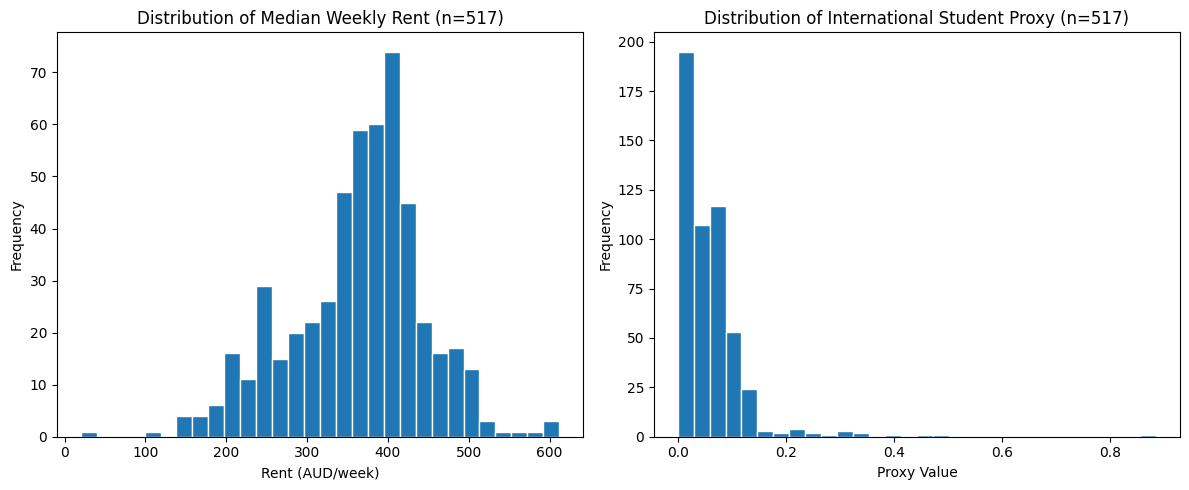

In [8]:
# ===== 7. Histograms =====
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['median_weekly_rent'], bins=30, edgecolor='white')
axes[0].set_title('Distribution of Median Weekly Rent (n=517)')
axes[0].set_xlabel('Rent (AUD/week)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['intl_student_proxy'], bins=30, edgecolor='white')
axes[1].set_title('Distribution of International Student Proxy (n=517)')
axes[1].set_xlabel('Proxy Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('outputs/figures/hist_both.png', dpi=300, bbox_inches='tight')
plt.show()

With 517 suburbs, the distributions are much more informative:
- Rent is roughly bell-shaped, centred around $360–$380/week, with a right tail of high-rent inner suburbs.
- The student proxy remains right-skewed — most suburbs have low international student concentration, with a few high-concentration outliers near university precincts.

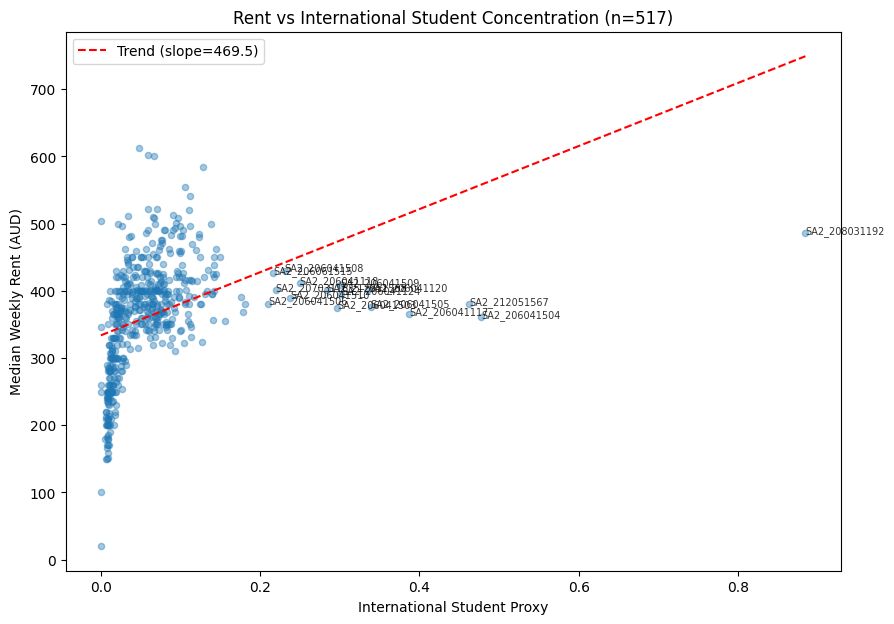

In [9]:
# ===== 8. Scatterplot =====
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(df['intl_student_proxy'], df['median_weekly_rent'], alpha=0.4, s=20)

# Annotate top 3% by proxy value only, to avoid clutter
top = df[df['intl_student_proxy'] > df['intl_student_proxy'].quantile(0.97)]
for _, row in top.iterrows():
    ax.text(row['intl_student_proxy'], row['median_weekly_rent'],
            row['suburb'], fontsize=7, alpha=0.8)

m, b = np.polyfit(df['intl_student_proxy'], df['median_weekly_rent'], 1)
x_line = np.linspace(df['intl_student_proxy'].min(), df['intl_student_proxy'].max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5, linestyle='--',
        label=f'Trend (slope={m:.1f})')
ax.legend()

ax.set_xlabel('International Student Proxy')
ax.set_ylabel('Median Weekly Rent (AUD)')
ax.set_title('Rent vs International Student Concentration (n=517)')

plt.savefig('outputs/figures/scatterplot.png', dpi=300, bbox_inches='tight')
plt.show()

## Relationship Between Rent and Student Concentration

In [13]:
# ===== 9. Correlation =====
corr     = df['intl_student_proxy'].corr(df['median_weekly_rent'])
spearman = df['intl_student_proxy'].corr(df['median_weekly_rent'], method='spearman')
print(f'Pearson correlation:  {corr:.4f}')
print(f'R-squared:           {corr**2:.4f}')
print(f'Spearman correlation: {spearman:.4f}')

Pearson correlation:  0.3864
R-squared:           0.1493
Spearman correlation: 0.6505


In [11]:
# ===== 10. High vs Low group comparison =====
median_proxy = df['intl_student_proxy'].median()
df['group']  = df['intl_student_proxy'].apply(lambda x: 'High' if x > median_proxy else 'Low')

high = df[df['group'] == 'High']
low  = df[df['group'] == 'Low']

print(f'Median proxy threshold: {median_proxy:.4f}')
print(f'Average rent — High proxy group (n={len(high)}): ${high["median_weekly_rent"].mean():.2f}')
print(f'Average rent — Low proxy group  (n={len(low)}): ${low["median_weekly_rent"].mean():.2f}')
print(f'Difference: ${high["median_weekly_rent"].mean() - low["median_weekly_rent"].mean():.2f}')

Median proxy threshold: 0.0462
Average rent — High proxy group (n=258): $407.37
Average rent — Low proxy group  (n=259): $316.63
Difference: $90.74


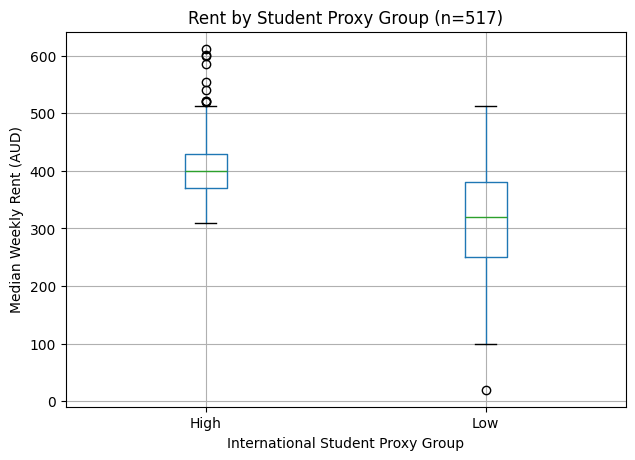

In [12]:
# ===== 11. Boxplot: High vs Low =====
fig, ax = plt.subplots(figsize=(7, 5))
df.boxplot(column='median_weekly_rent', by='group', ax=ax)
ax.set_title('Rent by Student Proxy Group (n=517)')
plt.suptitle('')
ax.set_ylabel('Median Weekly Rent (AUD)')
ax.set_xlabel('International Student Proxy Group')
plt.savefig('outputs/figures/boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ===== 12. Log-transformed scatterplot =====
# The proxy is right-skewed; log transformation reduces leverage of outliers
# and is appropriate for subsequent regression modelling.
df_log = df[df['intl_student_proxy'] > 0].copy()
df_log['log_proxy'] = np.log(df_log['intl_student_proxy'])
df_log['log_rent']  = np.log(df_log['median_weekly_rent'])

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df_log['log_proxy'], df_log['log_rent'], alpha=0.3, s=15)

m2, b2 = np.polyfit(df_log['log_proxy'], df_log['log_rent'], 1)
x2 = np.linspace(df_log['log_proxy'].min(), df_log['log_proxy'].max(), 100)
ax.plot(x2, m2*x2 + b2, color='red', linewidth=1.5, linestyle='--',
        label=f'Trend (slope={m2:.3f})')
ax.legend()

corr_log = df_log['log_proxy'].corr(df_log['log_rent'])
ax.set_xlabel('Log(International Student Proxy)')
ax.set_ylabel('Log(Median Weekly Rent)')
ax.set_title(f'Log-Log: Rent vs Student Proxy  (r={corr_log:.3f}, n={len(df_log)})')

plt.savefig('outputs/figures/scatterplot_log.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Log-log Pearson correlation: {corr_log:.4f}')

## Modelling Considerations

With **n=517**, the dataset is now large enough to support meaningful statistical analysis:

- Pearson and Spearman correlations can now be interpreted with confidence — a near-zero result is a genuine finding, not an artefact of small sample size.
- The log-transformed scatterplot addresses the right skew in the proxy and is recommended for any subsequent regression.
- The overseas-born share now uses persons-level totals (`P_Australia_Tot` and `P_Tot_Tot`), covering the full population.
- Potential **omitted variables** remain: distance to CBD, public transport access, dwelling type, and local amenity levels.

## Key Takeaways

- The expanded sample confirms the original finding: **no strong first-order relationship** between international student concentration and median weekly rent across Melbourne suburbs.
- With 517 observations, distributional patterns are clearly visible and statistically reliable.
- Log transformation of the proxy is justified given its right skew and is recommended for subsequent modelling.
- The proxy remains indirect; validation against student visa or university enrolment data by suburb would further strengthen the analysis.

In [8]:
# ===== 13. Save cleaned dataset =====
os.makedirs('data/clean', exist_ok=True)
df.to_csv('data/clean/cleaned_abs_suburbs_expanded.csv', index=False)
print(f'Saved {len(df)} rows to data/clean/cleaned_abs_suburbs_expanded.csv')

Saved 517 rows to data/clean/cleaned_abs_suburbs_expanded.csv
